Connected to DuckDB.
Starting Python EDA...

1. Customer segment analysis...
             customer_segment  customers  customer_percentage  avg_active_days  avg_page_visits  avg_searches  avg_cart_additions  avg_purchases
 Low-Engagement Non-Purchaser    9225684                41.37             1.08             1.21          0.00                0.00           0.00
          Other Non-Purchaser    5792981                25.98             2.21             8.41          0.08                0.16           0.00
Recently Active Non-Purchaser    5445286                24.42             2.50             7.20          0.05                0.09           0.00
   Search-Heavy Non-Purchaser     575007                 2.58             4.17            42.77          7.89                0.41           0.00
              Other Purchaser     473386                 2.12             4.88            34.81          3.01                2.15           1.54
     Cart-Heavy Non-Purchaser     350193             

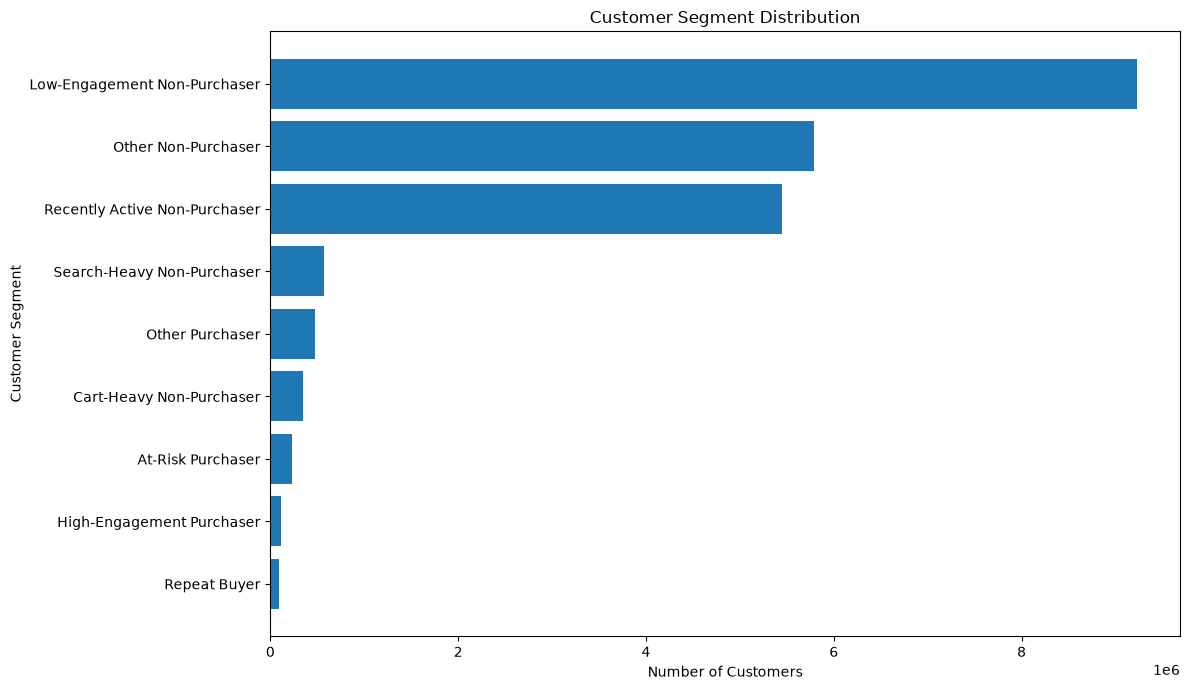


2. Purchaser vs non-purchaser analysis...
customer_type  customers  avg_active_days  avg_page_visits  avg_searches  avg_cart_additions  avg_cart_removals  avg_purchases
Non-Purchaser   21389151             1.92             6.99          0.37                0.18               0.05           0.00
    Purchaser     909210             6.36            54.86          5.90                3.97               1.76           2.55


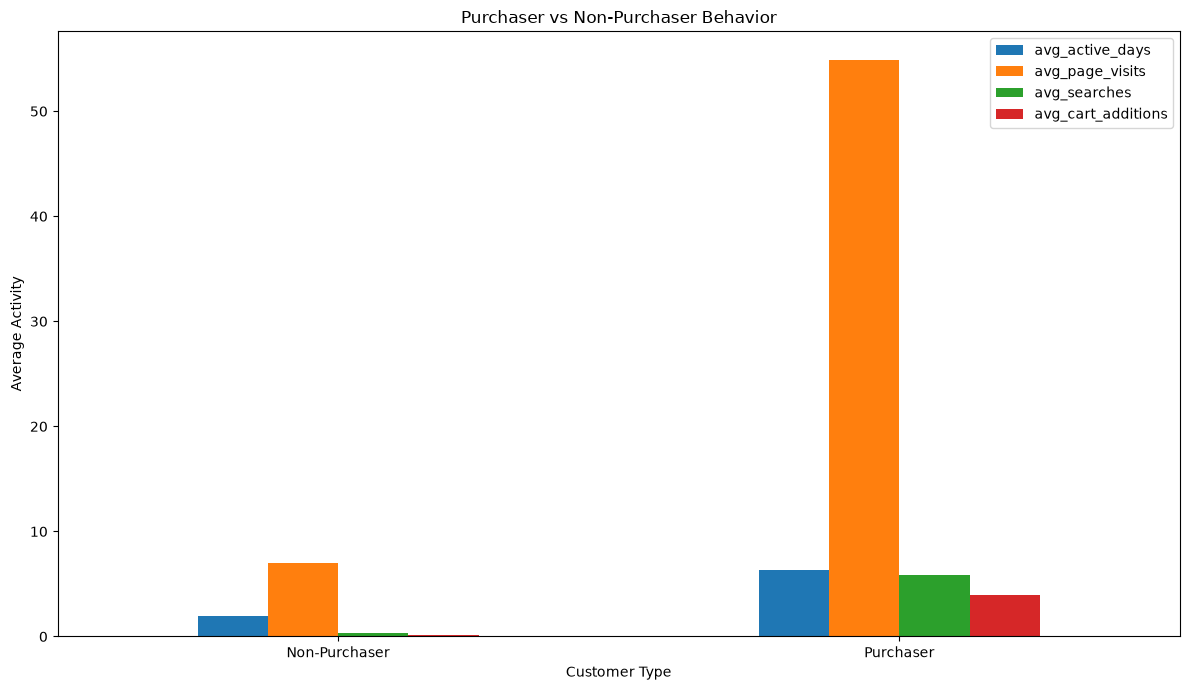


3. Customer recency analysis...


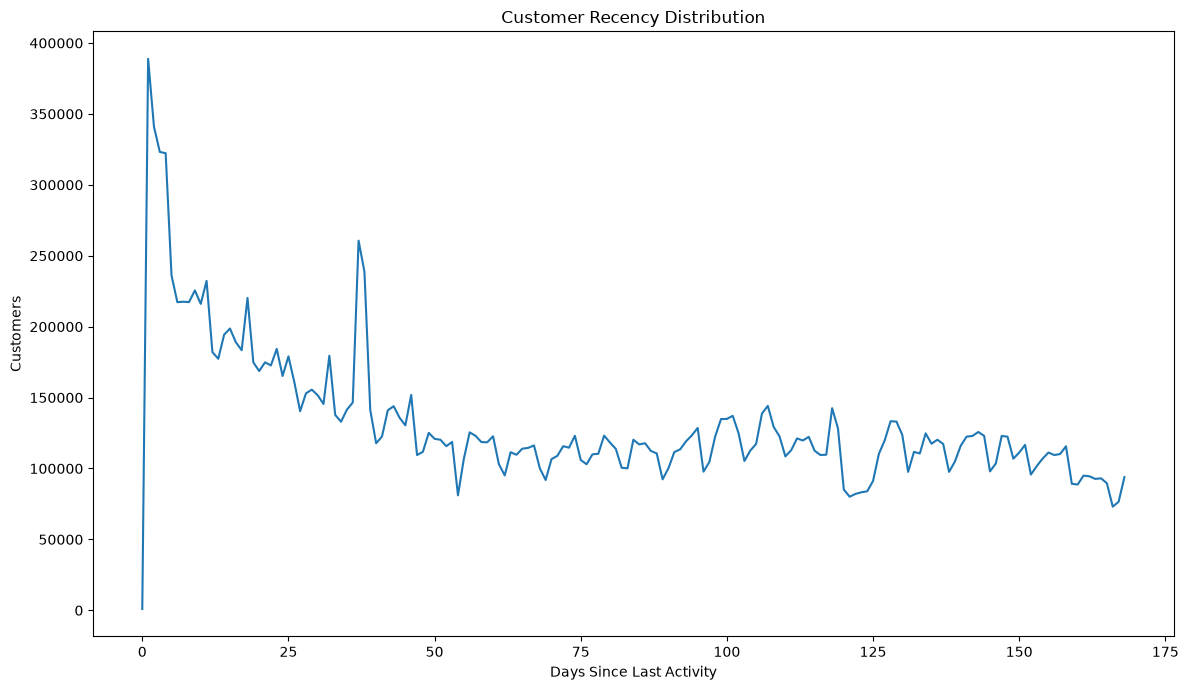


4. At-risk purchaser analysis...
 at_risk_customers  avg_active_days  avg_purchases  avg_page_visits  avg_days_since_last_activity
            228368             1.96           1.67            16.05                        126.14

5. Non-purchaser opportunity analysis...
             customer_segment  customers  avg_page_visits  avg_searches  avg_cart_additions  avg_total_interactions
 Low-Engagement Non-Purchaser    9225684             1.21          0.00                0.00                    1.21
          Other Non-Purchaser    5792981             8.41          0.08                0.16                    8.66
Recently Active Non-Purchaser    5445286             7.20          0.05                0.09                    7.36
   Search-Heavy Non-Purchaser     575007            42.77          7.89                0.41                   51.17
     Cart-Heavy Non-Purchaser     350193            73.96          7.41                6.40                   90.14

6. 24-hour cart conversion anal

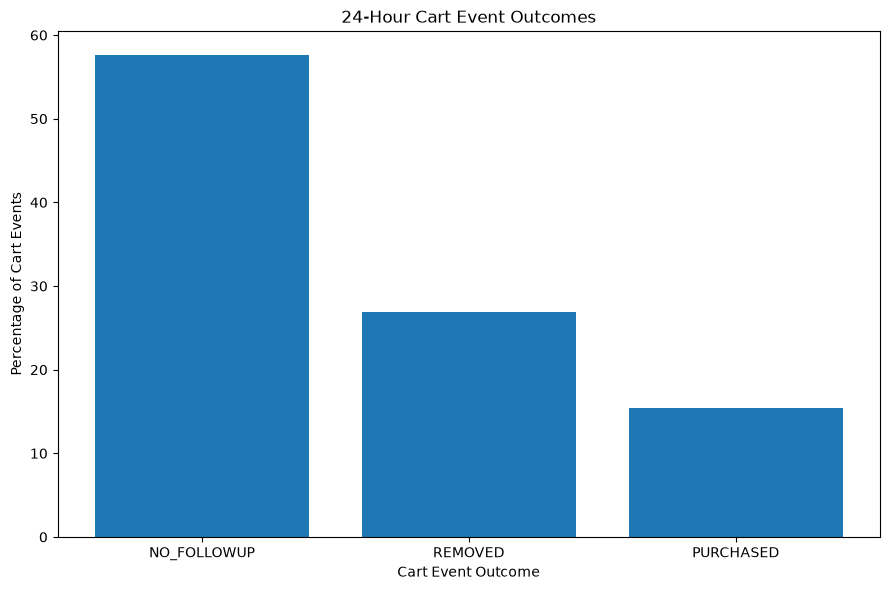


7. Purchase timing analysis...
time_bucket  purchases
    0-5 min     586606
   5-15 min     266289
  15-60 min     158340
  1-6 hours      70891
 6-24 hours      57046


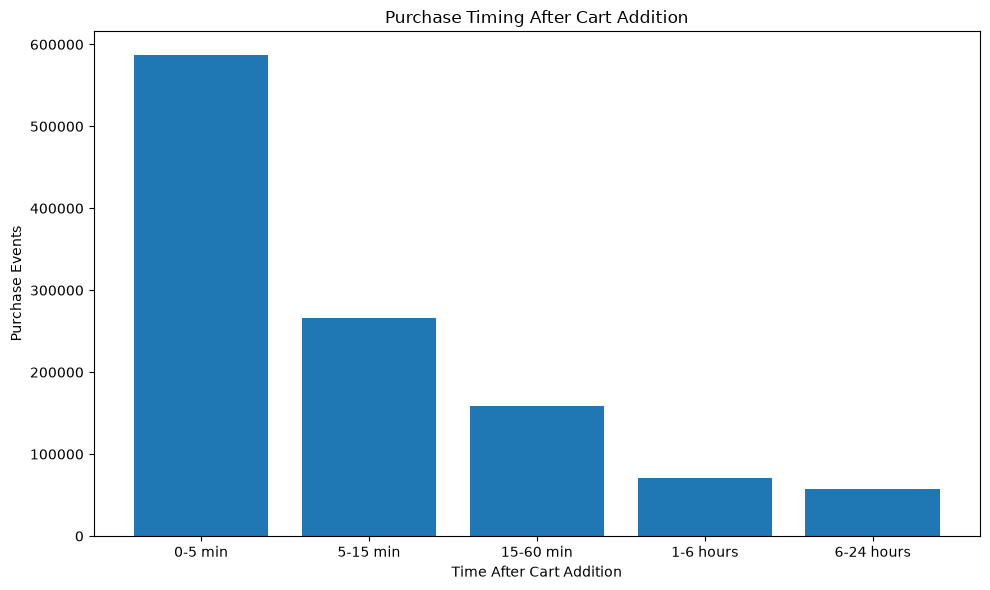


8. Product performance analysis...

Top products by purchase events:
    sku  category  price  cart_additions  cart_removals  purchase_events  unique_purchase_customers  purchase_per_cart_rate  cart_removal_rate
 219232       419     11            9130           3313             1957                       1510                  0.2143             0.3629
  52586      3398     27            7531           3163             1563                       1212                  0.2075             0.4200
 147718      5830     60            2403            667             1461                       1005                  0.6080             0.2776
1243077      5934      3            7374           2536             1319                       1042                  0.1789             0.3439
 940412      6794     47            3452           1217             1312                        955                  0.3801             0.3525
 561077      1135     33            5677           1998             1294

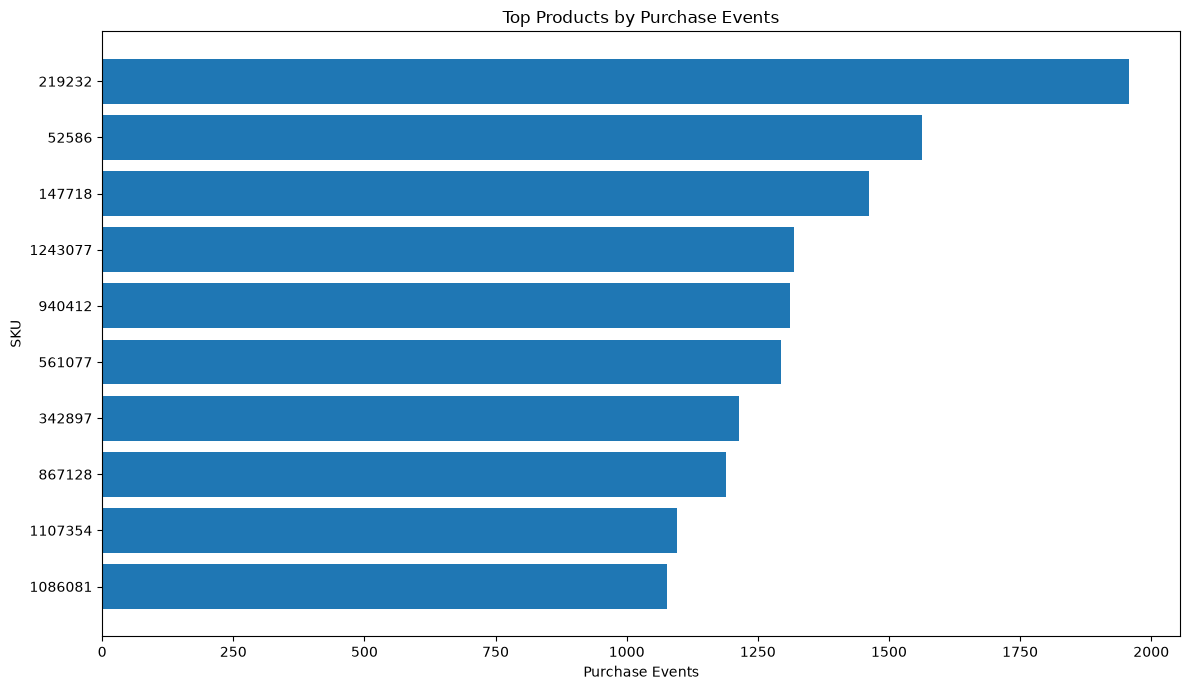


9. High-interest low-conversion products...
    sku  category  price  cart_additions  cart_removals  purchase_events  purchase_per_cart_rate  cart_removal_rate
  79226      6092     13              55              8                0                     0.0             0.1455
 972779      3633     29              66              9                0                     0.0             0.1364
 358884      3550     33              58              3                0                     0.0             0.0517
 659610       791     87              56             48                0                     0.0             0.8571
 396989      4299     48              75             27                0                     0.0             0.3600
 872872      1096      2              90             57                0                     0.0             0.6333
1316793      3266      1              57             54                0                     0.0             0.9474
 100028      6500     15   

In [4]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ============================================================
# CONFIGURATION
# ============================================================

DB_PATH = "ecommerce_analytics.duckdb"

OUTPUT_DIR = Path("eda_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

con = duckdb.connect(DB_PATH)

print("Connected to DuckDB.")
print("Starting Python EDA...\n")


# ============================================================
# 1. LOAD CUSTOMER SEGMENT SUMMARY
# ============================================================

print("1. Customer segment analysis...")

segment_df = con.execute("""
SELECT
    customer_segment,
    COUNT(*) AS customers,
    ROUND(
        COUNT(*) * 100.0 /
        SUM(COUNT(*)) OVER (),
        2
    ) AS customer_percentage,
    ROUND(AVG(active_days), 2) AS avg_active_days,
    ROUND(AVG(page_visits), 2) AS avg_page_visits,
    ROUND(AVG(searches), 2) AS avg_searches,
    ROUND(AVG(cart_additions), 2) AS avg_cart_additions,
    ROUND(AVG(purchases), 2) AS avg_purchases
FROM customer_segmentation
GROUP BY customer_segment
ORDER BY customers DESC
""").fetchdf()

print(segment_df.to_string(index=False))


# ============================================================
# 2. CUSTOMER SEGMENT DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 7))

plot_df = segment_df.sort_values(
    "customers",
    ascending=True
)

plt.barh(
    plot_df["customer_segment"],
    plot_df["customers"]
)

plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")
plt.title("Customer Segment Distribution")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "01_customer_segment_distribution.png",
    dpi=300
)

plt.show()


# ============================================================
# 3. PURCHASER VS NON-PURCHASER BEHAVIOR
# ============================================================

print("\n2. Purchaser vs non-purchaser analysis...")

purchaser_df = con.execute("""
SELECT

    CASE
        WHEN purchases > 0
        THEN 'Purchaser'
        ELSE 'Non-Purchaser'
    END AS customer_type,

    COUNT(*) AS customers,

    ROUND(AVG(active_days), 2)
        AS avg_active_days,

    ROUND(AVG(page_visits), 2)
        AS avg_page_visits,

    ROUND(AVG(searches), 2)
        AS avg_searches,

    ROUND(AVG(cart_additions), 2)
        AS avg_cart_additions,

    ROUND(AVG(cart_removals), 2)
        AS avg_cart_removals,

    ROUND(AVG(purchases), 2)
        AS avg_purchases

FROM customer_segmentation

GROUP BY customer_type

ORDER BY customer_type
""").fetchdf()

print(purchaser_df.to_string(index=False))


# ============================================================
# 4. PURCHASER VS NON-PURCHASER CHART
# ============================================================

comparison_df = purchaser_df.set_index(
    "customer_type"
)[[
    "avg_active_days",
    "avg_page_visits",
    "avg_searches",
    "avg_cart_additions"
]]

comparison_df.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.xlabel("Customer Type")
plt.ylabel("Average Activity")
plt.title("Purchaser vs Non-Purchaser Behavior")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "02_purchaser_vs_non_purchaser.png",
    dpi=300
)

plt.show()


# ============================================================
# 5. CUSTOMER RECENCY DISTRIBUTION
# ============================================================

print("\n3. Customer recency analysis...")

recency_df = con.execute("""
SELECT
    days_since_last_activity,
    COUNT(*) AS customers
FROM customer_segmentation
GROUP BY days_since_last_activity
ORDER BY days_since_last_activity
""").fetchdf()

# Limit chart to first 180 days so the distribution is readable

recency_plot = recency_df[
    recency_df["days_since_last_activity"] <= 180
]

plt.figure(figsize=(12, 7))

plt.plot(
    recency_plot["days_since_last_activity"],
    recency_plot["customers"]
)

plt.xlabel("Days Since Last Activity")
plt.ylabel("Customers")
plt.title("Customer Recency Distribution")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "03_customer_recency.png",
    dpi=300
)

plt.show()


# ============================================================
# 6. AT-RISK PURCHASER ANALYSIS
# ============================================================

print("\n4. At-risk purchaser analysis...")

at_risk_df = con.execute("""
SELECT

    COUNT(*) AS at_risk_customers,

    ROUND(AVG(active_days), 2)
        AS avg_active_days,

    ROUND(AVG(purchases), 2)
        AS avg_purchases,

    ROUND(AVG(page_visits), 2)
        AS avg_page_visits,

    ROUND(AVG(days_since_last_activity), 2)
        AS avg_days_since_last_activity

FROM customer_segmentation

WHERE customer_segment = 'At-Risk Purchaser'
""").fetchdf()

print(at_risk_df.to_string(index=False))


# ============================================================
# 7. NON-PURCHASER OPPORTUNITY
# ============================================================

print("\n5. Non-purchaser opportunity analysis...")

opportunity_df = con.execute("""
SELECT

    customer_segment,

    COUNT(*) AS customers,

    ROUND(AVG(page_visits), 2)
        AS avg_page_visits,

    ROUND(AVG(searches), 2)
        AS avg_searches,

    ROUND(AVG(cart_additions), 2)
        AS avg_cart_additions,

    ROUND(AVG(total_interactions), 2)
        AS avg_total_interactions

FROM customer_segmentation

WHERE purchases = 0

GROUP BY customer_segment

ORDER BY customers DESC
""").fetchdf()

print(opportunity_df.to_string(index=False))


# ============================================================
# 8. CART CONVERSION ANALYSIS
# ============================================================

print("\n6. 24-hour cart conversion analysis...")

cart_conversion_df = con.execute("""
SELECT

    outcome,

    COUNT(*) AS cart_events,

    ROUND(
        COUNT(*) * 100.0 /
        SUM(COUNT(*)) OVER (),
        2
    ) AS percentage

FROM cart_conversion_24h

GROUP BY outcome

ORDER BY cart_events DESC
""").fetchdf()

print(cart_conversion_df.to_string(index=False))


# ============================================================
# 9. CART CONVERSION CHART
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    cart_conversion_df["outcome"],
    cart_conversion_df["percentage"]
)

plt.xlabel("Cart Event Outcome")
plt.ylabel("Percentage of Cart Events")
plt.title("24-Hour Cart Event Outcomes")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "04_cart_conversion_24h.png",
    dpi=300
)

plt.show()


# ============================================================
# 10. PURCHASE TIMING AFTER CART ADDITION
# ============================================================

print("\n7. Purchase timing analysis...")

purchase_timing_df = con.execute("""
SELECT

    CASE

        WHEN seconds_to_outcome <= 5 * 60
            THEN '0-5 min'

        WHEN seconds_to_outcome <= 15 * 60
            THEN '5-15 min'

        WHEN seconds_to_outcome <= 60 * 60
            THEN '15-60 min'

        WHEN seconds_to_outcome <= 6 * 60 * 60
            THEN '1-6 hours'

        ELSE '6-24 hours'

    END AS time_bucket,

    COUNT(*) AS purchases

FROM cart_conversion_24h

WHERE outcome = 'PURCHASED'

GROUP BY time_bucket

ORDER BY
    CASE time_bucket

        WHEN '0-5 min' THEN 1
        WHEN '5-15 min' THEN 2
        WHEN '15-60 min' THEN 3
        WHEN '1-6 hours' THEN 4
        WHEN '6-24 hours' THEN 5

    END
""").fetchdf()

print(
    purchase_timing_df.to_string(index=False)
)

# ============================================================
# 11. PURCHASE TIMING CHART
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    purchase_timing_df["time_bucket"],
    purchase_timing_df["purchases"]
)

plt.xlabel("Time After Cart Addition")
plt.ylabel("Purchase Events")
plt.title("Purchase Timing After Cart Addition")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "05_purchase_timing.png",
    dpi=300
)

plt.show()


# ============================================================
# 12. PRODUCT PERFORMANCE
# ============================================================

print("\n8. Product performance analysis...")

product_df = con.execute("""
SELECT

    sku,
    category,
    price,
    cart_additions,
    cart_removals,
    purchase_events,
    unique_purchase_customers,
    purchase_per_cart_rate,
    cart_removal_rate

FROM product_behavior

WHERE cart_additions >= 100

ORDER BY purchase_events DESC

LIMIT 20
""").fetchdf()

print("\nTop products by purchase events:")
print(product_df.to_string(index=False))


# ============================================================
# 13. TOP PRODUCTS CHART
# ============================================================

top_products = product_df.head(10).copy()

top_products["sku"] = (
    top_products["sku"]
    .astype(str)
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_products["sku"],
    top_products["purchase_events"]
)

plt.xlabel("Purchase Events")
plt.ylabel("SKU")
plt.title("Top Products by Purchase Events")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "06_top_products.png",
    dpi=300
)

plt.show()


# ============================================================
# 14. HIGH-INTEREST LOW-CONVERSION PRODUCTS
# ============================================================

print("\n9. High-interest low-conversion products...")

low_conversion_products = con.execute("""
SELECT

    sku,
    category,
    price,
    cart_additions,
    cart_removals,
    purchase_events,
    purchase_per_cart_rate,
    cart_removal_rate

FROM product_behavior

WHERE cart_additions >= 50

ORDER BY purchase_per_cart_rate ASC

LIMIT 20
""").fetchdf()

print(
    low_conversion_products.to_string(index=False)
)


# ============================================================
# 15. CATEGORY PERFORMANCE
# ============================================================

print("\n10. Category performance...")

category_df = con.execute("""
SELECT

    category,

    SUM(cart_additions)
        AS cart_additions,

    SUM(purchase_events)
        AS purchase_events,

    COUNT(DISTINCT sku)
        AS products,

    ROUND(
        SUM(purchase_events) * 100.0 /
        NULLIF(SUM(cart_additions), 0),
        2
    ) AS purchase_per_cart_percentage

FROM product_behavior

GROUP BY category

HAVING SUM(cart_additions) >= 500

ORDER BY purchase_events DESC

LIMIT 20
""").fetchdf()

print(
    category_df.to_string(index=False)
)


# ============================================================
# 16. SAVE ANALYTICAL DATASETS
# ============================================================

segment_df.to_csv(
    OUTPUT_DIR / "customer_segments.csv",
    index=False
)

purchaser_df.to_csv(
    OUTPUT_DIR / "purchaser_vs_non_purchaser.csv",
    index=False
)

opportunity_df.to_csv(
    OUTPUT_DIR / "non_purchaser_opportunities.csv",
    index=False
)

cart_conversion_df.to_csv(
    OUTPUT_DIR / "cart_conversion_24h.csv",
    index=False
)

purchase_timing_df.to_csv(
    OUTPUT_DIR / "purchase_timing.csv",
    index=False
)

product_df.to_csv(
    OUTPUT_DIR / "top_products.csv",
    index=False
)

low_conversion_products.to_csv(
    OUTPUT_DIR / "low_conversion_products.csv",
    index=False
)

category_df.to_csv(
    OUTPUT_DIR / "category_performance.csv",
    index=False
)


# ============================================================
# 17. FINAL SUMMARY
# ============================================================

print("\n================================================")
print("PYTHON EDA COMPLETED SUCCESSFULLY")
print("================================================")

print(f"\nCharts and CSV files saved to:")
print(OUTPUT_DIR.resolve())

print("\nGenerated charts:")

print("1. 01_customer_segment_distribution.png")
print("2. 02_purchaser_vs_non_purchaser.png")
print("3. 03_customer_recency.png")
print("4. 04_cart_conversion_24h.png")
print("5. 05_purchase_timing.png")
print("6. 06_top_products.png")

print("\nEDA datasets:")
print("1. customer_segments.csv")
print("2. purchaser_vs_non_purchaser.csv")
print("3. non_purchaser_opportunities.csv")
print("4. cart_conversion_24h.csv")
print("5. purchase_timing.csv")
print("6. top_products.csv")
print("7. low_conversion_products.csv")
print("8. category_performance.csv")

con.close()